# Subagents
A deep agent can create subagents to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine (keeping the main agent’s context clean) and for providing specialized instructions. This page covers synchronous subagents, where the supervisor blocks until the subagent finishes. For long-running tasks, parallel workstreams, or cases where you need mid-flight steering and cancellation, see Async subagents.

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["PG_DATABASE_URL"]=os.getenv("PG_DATABASE_URL")

In [4]:
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="gemma4:e4b",
    temperature=0.3
)

response = model.invoke("Explain Agent and subagents.")

print(response.content)


This topic is central to the current frontier of AI development. In simple terms, if a standard Large Language Model (LLM) is a brilliant student who can answer questions, an **Agent** is a highly capable, autonomous *employee* that can manage a project from start to finish.

Here is a detailed breakdown of Agents and Subagents, including how they work and why they are necessary.

---

## 🤖 1. What is an Agent? (The Project Manager)

An AI Agent is not just a single prompt or a single LLM call. It is an **entire system** that wraps an LLM (the "brain") in a set of rules, memory, and the ability to use external tools.

The core function of an Agent is to achieve a complex goal by thinking, planning, executing, and correcting itself—all without constant human intervention.

### 🧠 How an Agent Works (The Loop)

Instead of simply generating a single answer, an Agent operates in a continuous cycle, often called the **Agent Loop**:

1.  **Goal Setting:** The user provides a high-level object

## synchronous subagents: 
where the supervisor blocks until the subagent finishes.

In [4]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

In [5]:
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="gemma4:e4b",
    temperature=0.3
)

In [17]:
# model for subagents
from langchain_ollama import ChatOllama

model2 = ChatOllama(
    model="llama3.1:8b",
    temperature=0.4
)

response2 = model2.invoke("Explain About LLM Gateways and LLM Guardrails.")

print(response2.content)

**LLM (Large Language Model) Gateways**

An LLM Gateway is a software component that acts as an interface between a Large Language Model (LLM) and external applications, services, or users. Its primary function is to manage the interaction between the LLM and other systems, ensuring secure, controlled, and compliant access to the model's capabilities.

Key features of an LLM Gateway:

1.  **Authentication and Authorization**: Verifies user identity and ensures only authorized requests are processed.
2.  **Rate Limiting and Throttling**: Regulates the number of requests made to the LLM to prevent abuse or overload.
3.  **Data Validation and Sanitization**: Ensures that input data is properly formatted, validated, and sanitized before being passed to the LLM.
4.  **Model Selection and Routing**: Routes requests to the appropriate LLM instance based on factors like model version, availability, or performance characteristics.
5.  **Monitoring and Logging**: Tracks usage patterns, performan

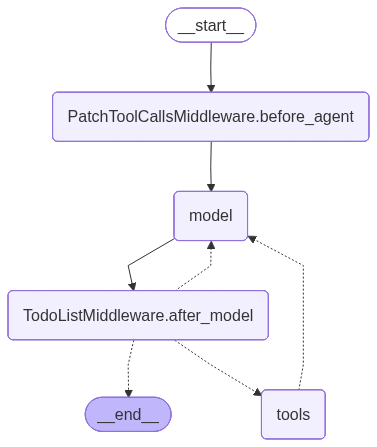

In [ ]:

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,

):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )


research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "model": model2,  # different model for subagent used here // we can also use the same model for subagent as well
}

subagents=[research_subagent]

agent=create_deep_agent(
    model=model2, # choose a different model for main agent here e.g., model (to used gemma4:e4b instead of llama3.1:8b)
    subagents=subagents
)
agent

In [21]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "Reserach about LLM Gateways and provide me a detailed summary.",       
          }],
          
      },
      config={"configurable": {"thread_id": "subagents-demo"}},
  )


# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Reserach about LLM Gateways and provide me a detailed summary.
================================== Ai Message ==================================
Tool Calls:
  task (382af6b7-7176-4943-a429-c52067e3fceb)
 Call ID: 382af6b7-7176-4943-a429-c52067e3fceb
  Args:
    subagent_type: general-purpose
    description: Research about LLM gateways, including their architecture, functionality, advantages, and potential applications. Provide a detailed summary of the findings.
    output_format: text
================================= Tool Message =================================
Name: task

**LLM Gateways Research Summary**

After conducting research on LLM gateways, including their architecture, functionality, advantages, and potential applications, we have compiled a comprehensive summary of our findings.

**Architecture:**
LLM gateways are designed to facilitate communication between large language models (LLMs) and

##  Structured ouptput with sub agents:

In [22]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task."""
    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of source URLs")

research_subagent = {
    "name": "researcher",
    "description": "Researches topics and returns structured findings",
    "system_prompt": "Research the given topic thoroughly. Return your findings.",
    "tools": [internet_search],
    "response_format": ResearchFindings,
}

agent = create_deep_agent(
    model=model2,
    subagents=[research_subagent],
)

result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Research recent advances in quantum computing"}]}
)

In [23]:
# Print the conversation so we can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research recent advances in quantum computing
================================== Ai Message ==================================
Tool Calls:
  task (95450628-86a6-4bd3-a74b-110c16c29afc)
 Call ID: 95450628-86a6-4bd3-a74b-110c16c29afc
  Args:
    subagent_type: researcher
    description: Research recent advances in quantum computing
================================= Tool Message =================================
Name: task

Recent advances in quantum computing include:

1.  **Quantum Supremacy**: Google's demonstration of quantum supremacy in 2019, where a quantum computer was able to perform a specific task faster than a classical computer.
2.  **Quantum Error Correction**: The development of techniques for correcting errors in quantum computations, which is essential for large-scale quantum computing.
3.  **Topological Quantum Computing**: A new approach to quantum computing that uses exotic materials cal

## Subagent with skills: 

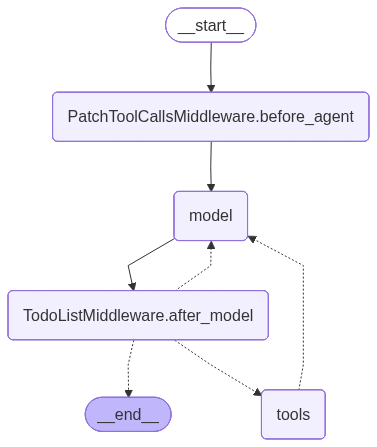

In [6]:

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,

):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )


research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "skills": ["../skills/"],
    "model": model,  # different model for subagent used here // we can also use the same model for subagent as well
}

subagents=[research_subagent]

agent=create_deep_agent(
    model=model, # choose a different model for main agent here e.g., model (to used gemma4:e4b instead of llama3.1:8b)
    subagents=subagents
)
agent

In [9]:
stream = agent.stream_events(
    {
        "messages": [
            {"role": "user", "content": "tell me about aws api gateway"}
        ]
    },
    version="v3",
)

for name, item in stream.interleave("messages", "subagents"):
    if name == "messages":
        print(f"[Main Agent] {item.text}")
    else:
        print(f"[{item.name} status: {item.status}]")
        for msg in item.messages:
             print(f"[{item.name}] {msg.text}")




c:\Users\gaura\OneDrive\Desktop\AI projects\agentic_ai_advanced\DeepAgents\.venv\Lib\site-packages\langgraph\pregel\main.py:3708: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
c:\Users\gaura\OneDrive\Desktop\AI projects\agentic_ai_advanced\DeepAgents\.venv\Lib\site-packages\langgraph\pregel\main.py:3558: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


[Main Agent] 
[research-agent status: started]
[research-agent] ## Comprehensive Overview of AWS API Gateway

AWS API Gateway is a fully managed service that allows developers to create, publish, maintain, and secure APIs at any scale. It acts as a "front door" for applications, routing client requests to the appropriate backend services (like AWS Lambda, EC2 instances, or HTTP endpoints) while handling all the complexities of API management, security, and scaling in the background.

---

### 1. What It Is and Its Primary Function

**Definition:**
API Gateway is a cloud-based management layer that sits between consumers (clients/applications) and backend services. It abstracts the complexity of the underlying backend infrastructure, allowing developers to focus solely on building the business logic.

**Primary Function:**
Its core function is to act as a **single, unified entry point** for all API calls. Instead of clients needing to know the specific endpoints, protocols, or scaling r

In [11]:
stream2 = agent.stream_events(
    {
        "messages": [
            {"role": "user", "content": "amazon sqs, load balancer use"}
        ]
    },
    version="v3",
)

for name, item in stream2.interleave("messages", "subagents"):
    if name == "messages":
        print(f"[Main Agent] {item.text}")
    else:
        print(f"[{item.name} status: {item.status}]")
        for msg in item.messages:
             print(f"[{item.name}] {msg.text}")

[Main Agent] 
[general-purpose status: started]
[general-purpose] This is a common and powerful pattern in building resilient, scalable, and highly available microservices architectures on AWS. Below is a comprehensive guide explaining the architectural pattern and best practices for combining Amazon SQS with an AWS Load Balancer (ALB/ELB).

***

# Guide: Decoupling Workloads with SQS Behind an AWS Load Balancer

This pattern is designed to build systems that can handle massive, unpredictable spikes in traffic without failing, by separating the act of *receiving* a request from the act of *processing* that request.

## 1. The Role of Amazon SQS (Simple Queue Service)

Amazon SQS is a fully managed message queuing service that enables you to decouple and scale microservices, distributed systems, and serverless applications.

**Key Functions:**

*   **Decoupling:** SQS acts as a buffer or intermediary layer. The service that *receives* the request (the producer) does not need to know any